<a href="https://colab.research.google.com/github/marciapaulasv-coder/TechChalenge/blob/main/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Visão Geral**

**Importação das Bibliotecas**

In [60]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn import*


**Carregamento das Bases**

In [61]:
AR = pd.read_csv("application_record.csv", sep = ",")
CR = pd.read_csv("credit_record.csv", sep = ",")

**Análise das Bases**

In [62]:
AR.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [63]:
CR.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [64]:
AR.shape

(438557, 18)

In [65]:
CR.shape

(1048575, 3)

In [66]:
AR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [67]:
CR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [68]:
AR.dtypes

,0
ID,int64
CODE_GENDER,object
FLAG_OWN_CAR,object
FLAG_OWN_REALTY,object
CNT_CHILDREN,int64
AMT_INCOME_TOTAL,float64
NAME_INCOME_TYPE,object
NAME_EDUCATION_TYPE,object
NAME_FAMILY_STATUS,object
NAME_HOUSING_TYPE,object


In [69]:
CR.dtypes

,0
ID,int64
MONTHS_BALANCE,int64
STATUS,object


In [70]:
AR.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [71]:
CR.describe()

,ID,MONTHS_BALANCE
count,1.048575e+06,1.048575e+06
mean,5.068286e+06,-1.913700e+01
std,4.615058e+04,1.402350e+01
min,5.001711e+06,-6.000000e+01
25%,5.023644e+06,-2.900000e+01
50%,5.062104e+06,-1.700000e+01
75%,5.113856e+06,-7.000000e+00
max,5.150487e+06,0.000000e+00


In [72]:
AR['ID'].nunique()

438510

In [73]:
CR['ID'].nunique()

45985

In [74]:
Comum_ID = len(set(AR['ID']) & set(CR['ID']))
print(Comum_ID)

36457


**Contagem de Valores Nulos nas colunas**

In [75]:
AR.isnull().sum().sort_values(ascending = False)

,0
OCCUPATION_TYPE,134203
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
CNT_CHILDREN,0
FLAG_OWN_REALTY,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
AMT_INCOME_TOTAL,0


<Axes: >

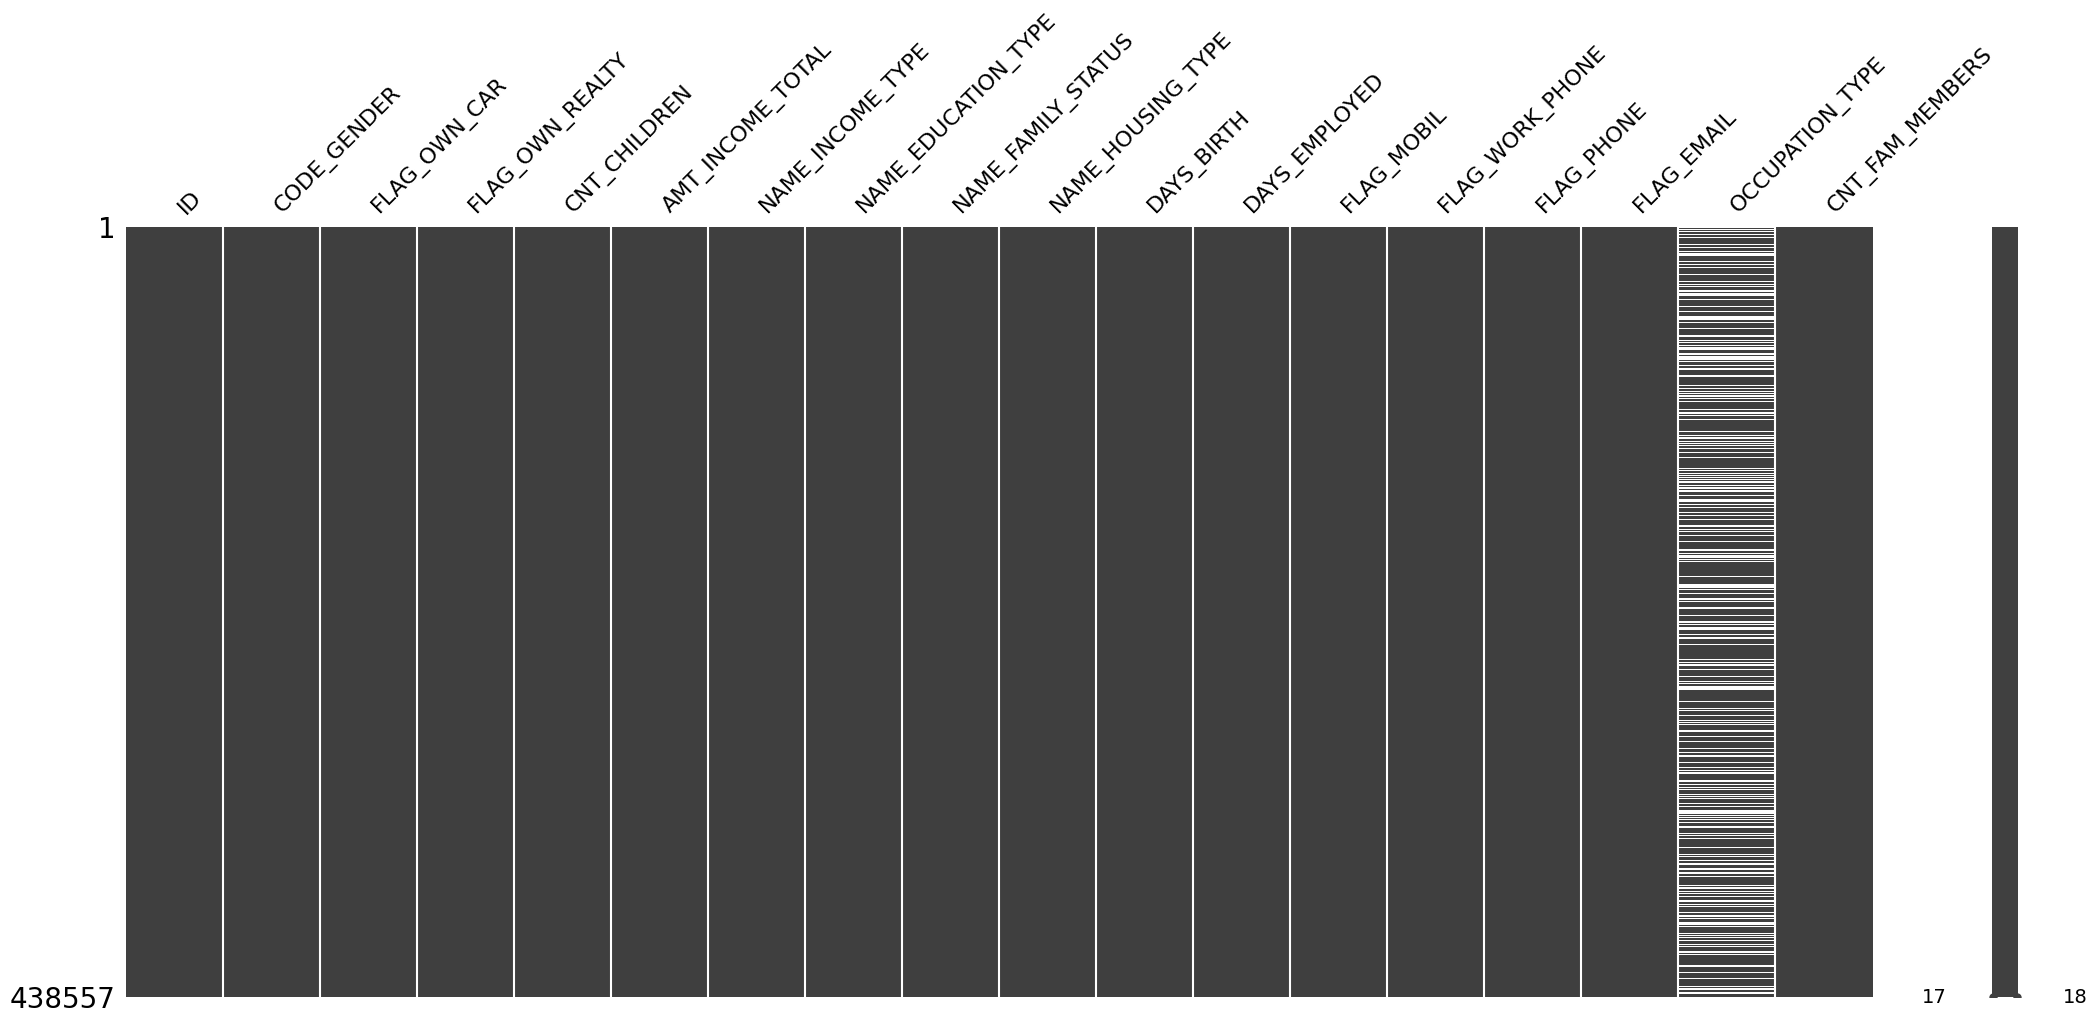

In [76]:
msno.matrix(AR)

In [77]:
ocupacao_nulos = AR[AR['OCCUPATION_TYPE'].isnull()]['NAME_INCOME_TYPE']

pd.DataFrame({
    'Quantidade': ocupacao_nulos.value_counts(),
    'Percentual (%)': ocupacao_nulos.value_counts(normalize=True).mul(100).round(2)
})

,Quantidade,Percentual (%)
NAME_INCOME_TYPE,,
Pensioner,75357,56.15
Working,35886,26.74
Commercial associate,16745,12.48
State servant,6210,4.63
Student,5,0.00


**Conclusão:** a variável "Tipo de ocupação" apresenta muitos valores nulos. Entre esses registros, 56,15% correspondem a pensionistas, seguidos por trabalhadores (26,74%).

**Dicionário da Variável Status**

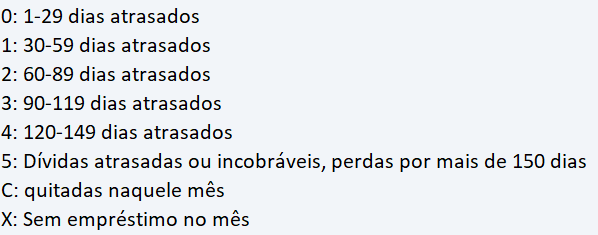

In [78]:
CR['STATUS'].value_counts(dropna=False)

,count
STATUS,
C,442031
0,383120
X,209230
1,11090
5,1693
2,868
3,320
4,223


In [79]:
(CR['STATUS'].value_counts(normalize=True) * 100).round(2)

,proportion
STATUS,
C,42.16
0,36.54
X,19.95
1,1.06
5,0.16
2,0.08
3,0.03
4,0.02


In [80]:
CR['ATRASO>30'] = CR['STATUS'].isin(['1', '2', '3', '4', '5']).astype(int)

CR['ATRASO>60'] = CR['STATUS'].isin(['2', '3', '4', '5']).astype(int)

In [81]:
comparacao_target = CR.groupby('ID')[['ATRASO>30', 'ATRASO>60']].max()

In [82]:
comparacao_target.sum()

,0
ATRASO>30,5350
ATRASO>60,667


In [83]:
(comparacao_target.mean() * 100).round(2)

,0
ATRASO>30,11.63
ATRASO>60,1.45


**Conclusão:** o critério de atraso superior a 60 dias identifica apenas 1,45% dos clientes, gerando uma base muito pequena. Por isso, foi adotado como TARGET o atraso igual ou superior a 30 dias, que representa 11,63% dos clientes e oferece uma quantidade maior de exemplos de "mau pagadores" para a modelagem.

In [84]:
CR['TARGET'] = CR['STATUS'].isin(['1', '2', '3', '4', '5']).astype(int)

**Conclusão:**  *Target 0* - Bom Pagador    *Target 1* - Mau Pagador

In [85]:
target_cliente = CR.groupby('ID')['TARGET'].max().reset_index()

In [86]:
target_cliente.head()

,ID,TARGET
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


In [87]:
target_cliente.shape

(45985, 2)

In [88]:
df = AR.merge(target_cliente, on='ID', how='inner')


In [89]:
df.shape

(36457, 19)

In [90]:
df['TARGET'].value_counts()

,count
TARGET,
0,32166
1,4291


In [91]:
(df['TARGET'].value_counts(normalize=True) * 100).round(2)

,proportion
TARGET,
0,88.23
1,11.77


**Conclusão:** 88,23% - Bons Pagadores
               11,77% - Maus Pagadores

In [92]:
df['PERFIL'] = df['TARGET'].map({0: 'Bom Pagador', 1: 'Mau Pagador'})

**2. Distribuição das Variáveis**

**A) RENDA**

***GRÁFICO BOXPLOT***

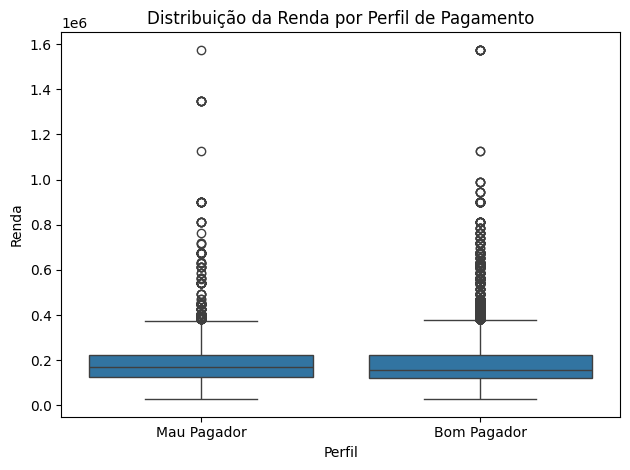

In [93]:
sns.boxplot(
    x='PERFIL',
    y='AMT_INCOME_TOTAL',
    data=df
)

plt.title('Distribuição da Renda por Perfil de Pagamento')
plt.xlabel('Perfil')
plt.ylabel('Renda')
plt.tight_layout()
plt.show()

**Conlusão**: como as caixas estão em alturas parecidas, pode se concluir que não há uma diferença de renda considerável entre os grupos de bons e maus pagadores. Além disso, as medianas e os intervalos entre quartis aparecem próximos e nos dois grupos observamos diversos valores de renda considerados outliers.

In [94]:
df.groupby('PERFIL')['AMT_INCOME_TOTAL'].agg(['count', 'mean', 'median']).round(2)

,count,mean,median
PERFIL,,,
Bom Pagador,32166,185785.99,157500.0
Mau Pagador,4291,193430.41,171000.0


**Conclusão**: os maus pagadores apresentam renda média e mediana um pouco superiores às dos bons pagadores. Portanto, maior renda não significa necessariamente menor risco de inadimplência.

**2) IDADE**

In [95]:
df['IDADE'] = (-df['DAYS_BIRTH'] / 365.25).astype(int)

Transformação da idade de dias para anos.

In [96]:
df[['DAYS_BIRTH', 'IDADE']].head()

,DAYS_BIRTH,IDADE
0,-12005,32
1,-12005,32
2,-21474,58
3,-19110,52
4,-19110,52


In [97]:
df['IDADE'].describe().round(2)

,IDADE
count,36457.00
mean,43.23
std,11.50
min,20.00
25%,34.00
50%,42.00
75%,53.00
max,68.00


É possível observar que a idade média dos clientes é 43 anos, mínimo 20 e máximo 68 anos.

***GRÁFICO HISTOGRAMA***

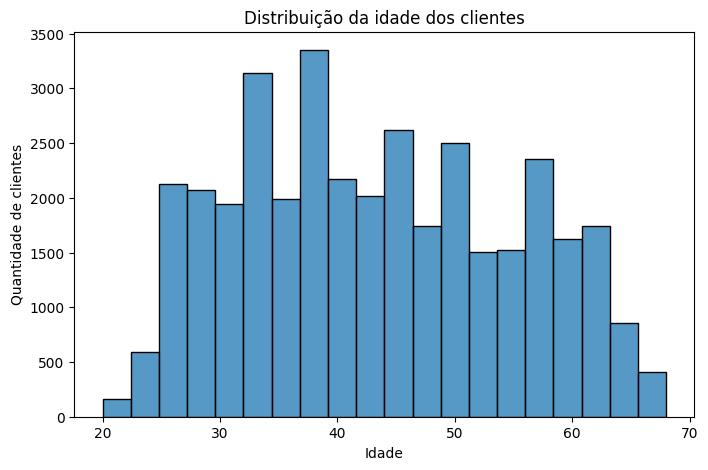

In [98]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='IDADE',
    bins=20
)

plt.title('Distribuição da idade dos clientes')
plt.xlabel('Idade')
plt.ylabel('Quantidade de clientes')

plt.show()

**Conclusão:** A idade dos clientes varia entre 20 e 68 anos, com maior concentração nas faixas intermediárias. Observa-se menor quantidade de clientes nas idades mais extremas.

In [99]:
df.groupby('PERFIL')['IDADE'].agg(['count', 'mean', 'median']).round(2)

,count,mean,median
PERFIL,,,
Bom Pagador,32166,43.35,42.0
Mau Pagador,4291,42.31,41.0


**Conclusão:** a diferença de idade entre os bons e maus pagadores é pequena. Então a idade, isoladamente, não parece diferenciar os dois perfis de pagamento.

***GRÁFICO BOXPLOT***

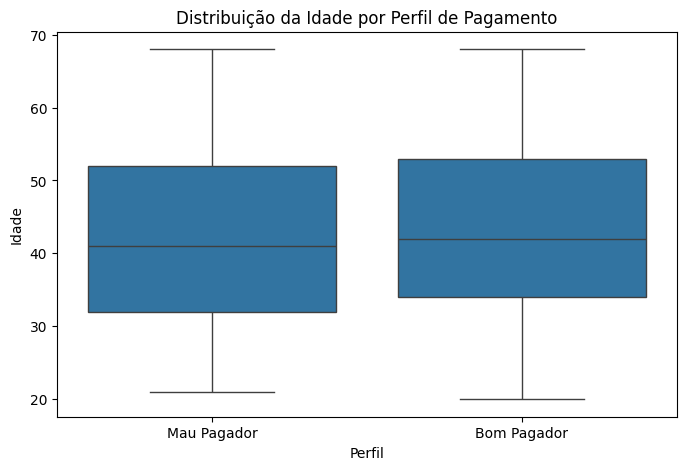

In [100]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='PERFIL',
    y='IDADE'
)

plt.title('Distribuição da Idade por Perfil de Pagamento')
plt.xlabel('Perfil')
plt.ylabel('Idade')

plt.show()

**Conclusão:** As distribuições de idade dos bons e maus pagadores são bastante semelhantes. Os maus pagadores apresentam idade média e mediana um pouco inferiores. Conforme já observado no Histograma, a idade isoladamente não demonstra grande capacidade de diferenciar bons e maus pagadores.

**C)TEMPO DE EMPREGO**

In [101]:
df['DAYS_EMPLOYED'].describe().round(2)

,DAYS_EMPLOYED
count,36457.00
mean,59262.94
std,137651.33
min,-15713.00
25%,-3153.00
50%,-1552.00
75%,-408.00
max,365243.00


In [102]:
df[df['DAYS_EMPLOYED'] == 365243].shape[0]

6135

In [103]:
df[df['DAYS_EMPLOYED'] == 365243]['NAME_INCOME_TYPE'].value_counts()

,count
NAME_INCOME_TYPE,
Pensioner,6135


**Conclusão:** Foram identificados 6.135 clientes com DAYS_EMPLOYED = 365243, ou seja, 1.000 anos, valor incompatível. Todos os registros pertencem à categoria Pensioner, indicando que o valor não deve ser considerado como tempo efetivo de emprego, podendo ser um código.


In [104]:
df['ANOS_EMPREGADO'] = np.where(
    df['DAYS_EMPLOYED'] == 365243,
    np.nan,
    -df['DAYS_EMPLOYED'] / 365.25
)

In [105]:
df['ANOS_EMPREGADO'].describe().round(2)

,ANOS_EMPREGADO
count,30322.00
mean,7.24
std,6.45
min,0.05
25%,2.68
50%,5.45
75%,9.60
max,43.02


**Conclusão:** Desconsiderando os 6135 clientes com 'DAYS_EMPLOYED' 365243, o tempo médio de emprego é de 7,24 anos, com valores variando de aproximadamente 0,05 a 43 anos.

In [106]:
df.groupby('PERFIL')['ANOS_EMPREGADO'].agg(
    ['count', 'mean', 'median']
).round(2)

,count,mean,median
PERFIL,,,
Bom Pagador,26658,7.25,5.49
Mau Pagador,3664,7.16,5.21


**Conclusão:** O tempo de emprego é muito semelhante entre bons e maus pagadores. Os bons pagadores apresentam média de 7,25 anos, enquanto os maus apresentam 7,16 anos. O tempo de emprego também não parece distinguir de forma relevante os dois perfis.

**GRÁFICO BOXPLOT**

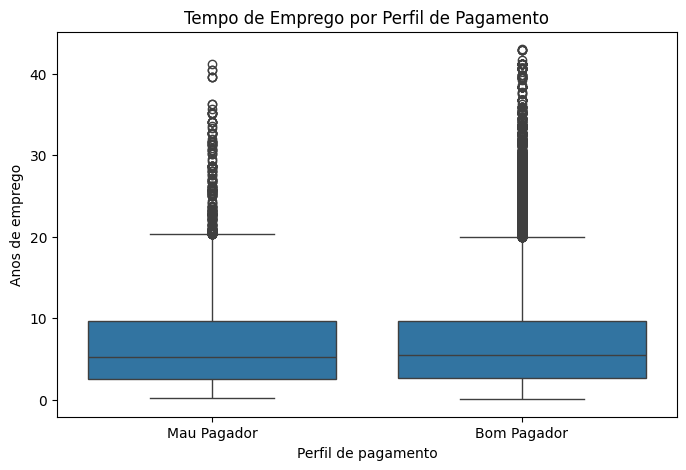

In [107]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='PERFIL',
    y='ANOS_EMPREGADO'
)

plt.title('Tempo de Emprego por Perfil de Pagamento')
plt.xlabel('Perfil de pagamento')
plt.ylabel('Anos de emprego')

plt.show()

**Conclusão:** O gráfico mostra mais uma vez que o tempo de emprego apresenta distribuição bastante semelhante entre bons e maus pagadores, com médias de 7,25 e 7,16 anos, respectivamente. O boxplot identifica diversos valores acima de aproximadamente 20 anos (outliers).

**D) QUANTIDADE DE FILHOS**

In [108]:
df['CNT_CHILDREN'].describe().round(2)

,CNT_CHILDREN
count,36457.00
mean,0.43
std,0.74
min,0.00
25%,0.00
50%,0.00
75%,1.00
max,19.00


In [109]:
df['CNT_CHILDREN'].value_counts().sort_index()

,count
CNT_CHILDREN,
0,25201
1,7492
2,3256
3,419
4,63
5,20
7,2
14,3
19,1


In [110]:
df.groupby('PERFIL')['CNT_CHILDREN'].agg(
    ['count', 'mean', 'median']
).round(2)

,count,mean,median
PERFIL,,,
Bom Pagador,32166,0.43,0.0
Mau Pagador,4291,0.45,0.0


In [111]:
analise_filhos = df.groupby('CNT_CHILDREN').agg(Quantidade=('TARGET', 'count'),
    Taxa_Maus_Pagadores=('TARGET', 'mean'))

analise_filhos['Taxa_Maus_Pagadores'] = (analise_filhos['Taxa_Maus_Pagadores'] * 100).round(2)

analise_filhos

,Quantidade,Taxa_Maus_Pagadores
CNT_CHILDREN,,
0,25201,11.67
1,7492,11.35
2,3256,13.36
3,419,13.13
4,63,7.94
5,20,0.00
7,2,100.00
14,3,66.67
19,1,0.00


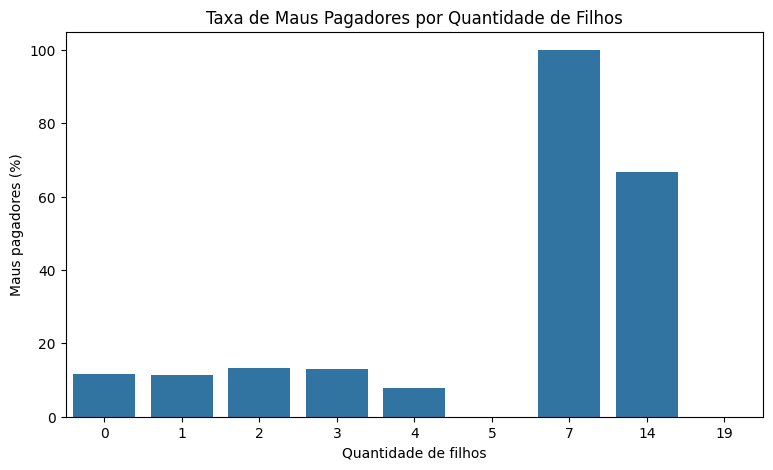

In [112]:
plt.figure(figsize=(9, 5))

sns.barplot(x=analise_filhos.index,y=analise_filhos['Taxa_Maus_Pagadores'])

plt.title('Taxa de Maus Pagadores por Quantidade de Filhos')
plt.xlabel('Quantidade de filhos')
plt.ylabel('Maus pagadores (%)')

plt.show()

**Conclusão:** A maior parte dos clientes possui entre 0 e 2 filhos. Entre os grupos com maior quantidade de registros, as taxas de maus pagadores são relativamente próximas, variando de 11,35% a 13,36%. Algumas categorias com maior número de filhos apresentam taxas extremas, porém possuem pouquíssimos clientes. De forma geral, a quantidade de filhos, isoladamente, não apresenta uma relação clara com o perfil de pagamento.

E) TAMANHO DAS FAMÍLIAS

In [113]:
df['CNT_FAM_MEMBERS'].describe().round(2)

,CNT_FAM_MEMBERS
count,36457.00
mean,2.20
std,0.91
min,1.00
25%,2.00
50%,2.00
75%,3.00
max,20.00


In [114]:
df['CNT_FAM_MEMBERS'].value_counts().sort_index()

,count
CNT_FAM_MEMBERS,
1.0,6987
2.0,19463
3.0,6421
4.0,3106
5.0,397
6.0,58
7.0,19
9.0,2
15.0,3


In [115]:
df.groupby('PERFIL')['CNT_FAM_MEMBERS'].agg(['count', 'mean', 'median']).round(2)

,count,mean,median
PERFIL,,,
Bom Pagador,32166,2.20,2.0
Mau Pagador,4291,2.22,2.0


In [116]:
analise_familia = df.groupby('CNT_FAM_MEMBERS').agg(Quantidade=('TARGET', 'count'),Taxa_Maus_Pagadores=('TARGET', 'mean'))

analise_familia['Taxa_Maus_Pagadores'] = (analise_familia['Taxa_Maus_Pagadores'] * 100).round(2)

analise_familia

,Quantidade,Taxa_Maus_Pagadores
CNT_FAM_MEMBERS,,
1.0,6987,11.81
2.0,19463,11.63
3.0,6421,11.26
4.0,3106,13.62
5.0,397,12.09
6.0,58,8.62
7.0,19,0.00
9.0,2,100.00
15.0,3,66.67


In [117]:
plt.figure(figsize=(9, 5))

sns.barplot(x=taxa_familia.index, y=taxa_familia.values)

plt.title('Taxa de Maus Pagadores por Tamanho da Família')
plt.xlabel('Quantidade de pessoas na família')
plt.ylabel('Maus pagadores (%)')

plt.show()

NameError: name 'taxa_familia' is not defined

<Figure size 900x500 with 0 Axes>

**Conclusão:** A maior parte das famílias tem 2 pessoas. Entre familias com 1 a 5 pessoas, as taxas de maus pagadores são relativamente próximas, variando de 11,26 a 13,62%. A categorias com maior número de pessoas (6 ou mais) uma quantidade pequena de famílias, por isso não é atribuída considerável importância. De forma geral, também a quantidade de pessoas em uma família, isoladamente, não apresenta uma relação clara com o perfil de pagamento.

**3) Correlações**

In [ ]:
df.head()

In [ ]:
set(df.FLAG_MOBIL)

In [ ]:
variaveis_correlacao = [
    'CNT_CHILDREN',
    'AMT_INCOME_TOTAL',
    'CNT_FAM_MEMBERS',
    'IDADE',
    'ANOS_EMPREGADO',
    'FLAG_PHONE',
    'TARGET'
]

Foram excluídas as variáveis 'FLAG_MOBIL' porque não tem variação, todos os registros são 1, a FLAG_WORK_FONE porque não foi considerada importante, as variáveis que geraram as colunas idade e qtde. de anos de emprego, e ainda as que não são numéricas.

In [ ]:
correlacao = df[variaveis_correlacao].corr().round(2)

print(correlacao)

**Conclusão:** nenhuma variável tem correlação significativa com o Target (Bons ou Maus Pagadores). As variáveis quantidade de filhos e quantidade de membros na família, apresentaram correlação importante (0,89), o que faz todo sentido (mais filhos, maior qtde. de pessoas na família). Uma outra correlação considerável, mas esperada é a de idade e anos de emprego - pesssoas com mais idade, estão há mais anos no emprego.

In [ ]:
plt.figure(figsize=(10, 7))

sns.heatmap(correlacao, annot=True, cmap='coolwarm',fmt='.2f')

plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()

**Conclusão:** a matriz de correlação indica que as variáveis numéricas analisadas apresentam pouca correlação com o TARGET, com valores próximos de zero. Sendo assim, nenhuma das variáveis numéricas analisadas, isoladamente, apresenta forte relação com o perfil de pagamento. A maior correlação observada ocorre entre quantidade de filhos (CNT_CHILDREN) e tamanho da família (CNT_FAM_MEMBERS) - 0,89. Também se observa correlação positiva razoável entre idade e tempo de emprego (0,34).

**4) Outliers**

In [ ]:
Q1 = df['AMT_INCOME_TOTAL'].quantile(0.25)
Q3 = df['AMT_INCOME_TOTAL'].quantile(0.75)

IQR = Q3 - Q1

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)